In [3]:
import duckdb as dd
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_parquet("geoeditors_aggregate.parquet")

In [5]:
df

,wiki_db,country,high_activity,lower_editor_bound,upper_editor_bound,year,month
0,abwiki,Czech Republic,True,1,10,2025,8
1,afwiki,Belgium,False,1,10,2025,8
2,afwiki,Bulgaria,True,1,10,2025,8
3,afwiki,Canada,False,1,10,2025,8
4,afwiki,Finland,False,1,10,2025,8
...,...,...,...,...,...,...,...
317616,zuwiki,Brazil,False,1,10,2021,7
317617,zuwiki,Italy,False,1,10,2021,7
317618,zuwiki,South Africa,True,1,10,2021,7
317619,zuwiki,South Africa,False,1,10,2021,7


In [6]:
print(df.wiki_db.count())

317621


In [7]:
df.wiki_db.value_counts()

wiki_db
enwiki     24861
frwiki     13346
eswiki     10406
dewiki      9361
ruwiki      8416
           ...  
tddwiki        5
annwiki        5
rkiwiki        4
nupwiki        2
tigwiki        1
Name: count, Length: 346, dtype: int64

In [8]:
df.country.value_counts()

country
United States        16494
Germany              14279
unknown              13132
United Kingdom       10392
France                9920
                     ...  
Nauru                    2
Wallis and Futuna        2
Tuvalu                   1
Pitcairn Islands         1
Bouvet Island            1
Name: count, Length: 223, dtype: int64

In [9]:
df.high_activity.value_counts()

high_activity
False    244702
True      72919
Name: count, dtype: int64

In [10]:
df.lower_editor_bound.describe()

count    317621.000000
mean         40.373121
std         479.513799
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max       28061.000000
Name: lower_editor_bound, dtype: float64

In [11]:
df.upper_editor_bound.describe()

count    317621.000000
mean         49.373121
std         479.513799
min          10.000000
25%          10.000000
50%          10.000000
75%          10.000000
max       28070.000000
Name: upper_editor_bound, dtype: float64

In [12]:
dd.sql("SELECT * FROM df WHERE wiki_db = 'enwiki' AND country = 'United States' ORDER BY year DESC, month DESC")

┌─────────┬───────────────┬───────────────┬────────────────────┬────────────────────┬───────┬───────┐
│ wiki_db │    country    │ high_activity │ lower_editor_bound │ upper_editor_bound │ year  │ month │
│ varchar │    varchar    │    boolean    │       int64        │       int64        │ int32 │ int32 │
├─────────┼───────────────┼───────────────┼────────────────────┼────────────────────┼───────┼───────┤
│ enwiki  │ United States │ true          │               2021 │               2030 │  2025 │    10 │
│ enwiki  │ United States │ false         │              21111 │              21120 │  2025 │    10 │
│ enwiki  │ United States │ true          │               2021 │               2030 │  2025 │     9 │
│ enwiki  │ United States │ false         │              20261 │              20270 │  2025 │     9 │
│ enwiki  │ United States │ true          │               1981 │               1990 │  2025 │     8 │
│ enwiki  │ United States │ false         │              17621 │              1763

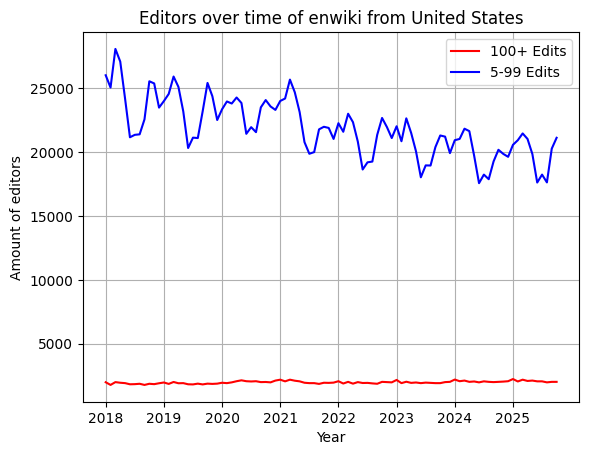

In [35]:
enwiki_US_highAct = dd.sql(
"""
SELECT 
    lower_editor_bound AS amt, 
    (year * 12) + month - 1 AS time 
FROM df 
WHERE 
    wiki_db = 'enwiki' 
    AND country = 'United States' 
    AND high_activity = TRUE 
ORDER BY time""").df()

enwiki_US_lowAct = dd.sql(
"""
SELECT 
    lower_editor_bound AS amt, 
    (year * 12) + month - 1 AS time 
FROM df 
WHERE 
    wiki_db = 'enwiki' 
    AND country = 'United States' 
    AND high_activity = FALSE 
ORDER BY time""").df()

plt.plot(enwiki_US_highAct['time'], enwiki_US_highAct['amt'], 'r-', label='100+ Edits')
plt.plot(enwiki_US_lowAct['time'], enwiki_US_lowAct['amt'], 'b-', label='5-99 Edits')

begin_year_range = int(dd.sql("SELECT MIN(year) FROM df WHERE wiki_db = 'enwiki' AND country = 'United States'").df().values[0, 0])
end_year_range = int(dd.sql("SELECT MAX(year) FROM df WHERE wiki_db = 'enwiki' AND country = 'United States'").df().values[0, 0]) + 1

ticks = [year * 12 for year in range(begin_year_range, end_year_range)]

labels = [str(year) for year in range(begin_year_range, end_year_range)]

plt.xticks(ticks, labels)
plt.grid()
plt.xlabel("Year")
plt.ylabel("Amount of editors")
plt.title("Editors over time of enwiki from United States")
plt.legend()
plt.show()

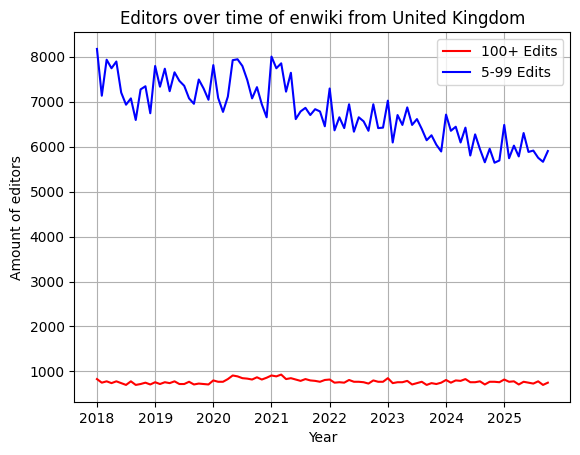

In [33]:
enwiki_UK_highAct = dd.sql(
"""
SELECT 
    lower_editor_bound AS amt, 
    (year * 12) + month - 1 AS time 
FROM df 
WHERE 
    wiki_db = 'enwiki' 
    AND country = 'United Kingdom' 
    AND high_activity = TRUE 
ORDER BY time""").df()

enwiki_UK_lowAct = dd.sql(
"""
SELECT 
    lower_editor_bound AS amt, 
    (year * 12) + month - 1 AS time 
FROM df 
WHERE 
    wiki_db = 'enwiki' 
    AND country = 'United Kingdom' 
    AND high_activity = FALSE 
ORDER BY time""").df()

plt.plot(enwiki_UK_highAct['time'], enwiki_UK_highAct['amt'], 'r-', label='100+ Edits')
plt.plot(enwiki_UK_lowAct['time'], enwiki_UK_lowAct['amt'], 'b-', label='5-99 Edits')

begin_year_range = int(dd.sql("SELECT MIN(year) FROM df WHERE wiki_db = 'enwiki' AND country = 'United Kingdom'").df().values[0, 0])
end_year_range = int(dd.sql("SELECT MAX(year) FROM df WHERE wiki_db = 'enwiki' AND country = 'United Kingdom'").df().values[0, 0]) + 1

ticks = [year * 12 for year in range(begin_year_range, end_year_range)]

labels = [str(year) for year in range(begin_year_range, end_year_range)]

plt.xticks(ticks, labels)
plt.grid()
plt.xlabel("Year")
plt.ylabel("Amount of editors")
plt.title("Editors over time of enwiki from United Kingdom")
plt.legend()
plt.show()